In [1]:
import os
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
import joblib

In [ ]:
# 設定主題
title = 'qLNEHVI'
# 讀取資料
pkl_dir = '/workspaces/BO_EXPERIMENTS/src/results/20260205/mobo_lasso_generater'
pkl_path_ls = [os.path.join(pkl_dir, n) for n in os.listdir(pkl_dir)]

hv_data_ls = []
for pkl_path in pkl_path_ls:
    data_info = joblib.load(pkl_path)
    hv_data_ls.append(data_info)

In [ ]:
hv_data_ls[0].keys()

In [ ]:
# 根據存檔的超體積資訊繪圖
colors = plt.cm.tab10.colors
plt.figure(figsize=(10, 5))
for i, hv_data in enumerate(hv_data_ls):
    color = colors[i % 10] # 使用固定 10 色循環
    seed = hv_data['datasplit_seed']
    hv_ls = hv_data['hv_ls']
    plt.plot(hv_ls, linestyle='-', color=color, label='Seed: {}'.format(seed))

# 加入標題與標籤
plt.title('MOBO Hyper Volume From Acqui {}'.format(title))
plt.xlabel('Iter')
plt.ylabel('Volume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 4. 顯示圖表
plt.show()

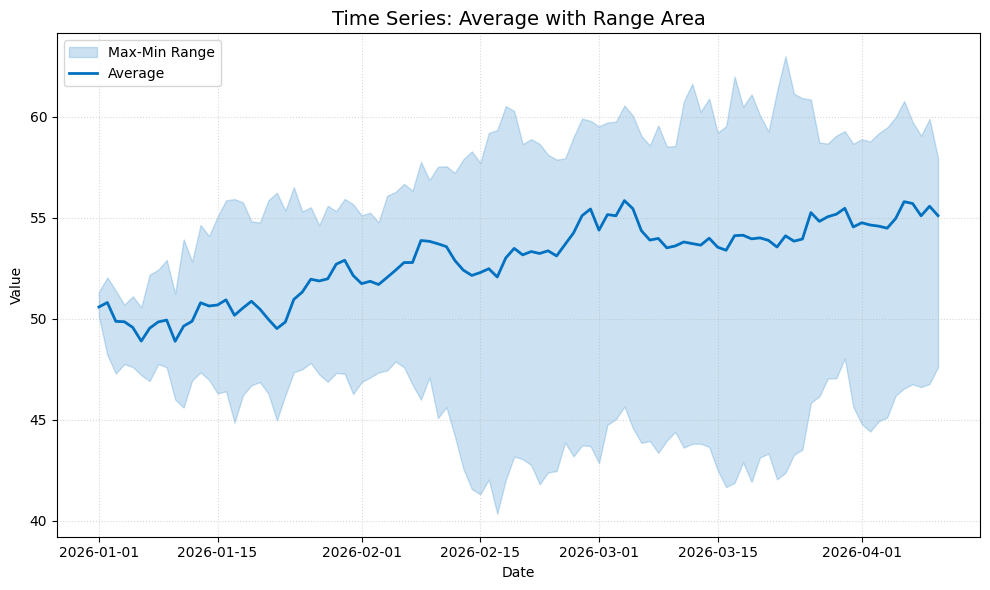

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 產生模擬數據 (假設你有四串時間序列)
np.random.seed(10)
dates = pd.date_range(start="2026-01-01", periods=100)
data = {
    'A': np.cumsum(np.random.randn(100)) + 50,
    'B': np.cumsum(np.random.randn(100)) + 50,
    'C': np.cumsum(np.random.randn(100)) + 50,
    'D': np.cumsum(np.random.randn(100)) + 50
}
df = pd.DataFrame(data, index=dates)

# 2. 計算統計值
df['mean'] = df.mean(axis=1)
df['max'] = df.max(axis=1)
df['min'] = df.min(axis=1)

# 3. 繪圖
plt.figure(figsize=(10, 6))

# 定義主題顏色
main_blue = '#0070C0' # 標準藍色

# 繪製最高與最低的區間：使用 alpha 設定透明度
plt.fill_between(
    df.index, 
    df['min'], 
    df['max'], 
    color=main_blue, 
    alpha=0.2,       # 設定透明度為 20%
    label='Max-Min Range'
)

# 繪製平均線
plt.plot(
    df.index, 
    df['mean'], 
    color=main_blue, 
    linewidth=2, 
    label='Average'
)

# 圖表美化
plt.title("Time Series: Average with Range Area", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()